In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import svm

In [2]:
#loading dataset
data = pd.read_csv("diabetes_data.csv")

In [4]:
# now feature selection and target variable selection

# extracting features all columns not last one 
X = data.iloc[:, :-1].values
Y = data.iloc[:, -1].values
Y_binary = np.where(Y == 0, -1, 1)

In [5]:
#spilliting data 70 for training and 30 for testing
X_train, X_test, Y_train, Y_test = train_test_split(X, Y_binary, test_size=0.3, random_state=45)

In [6]:
#train and predict with KNN
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, Y_train)
Y_pred_knn = knn.predict(X_test)

#train and predict with naive bayes
nb = GaussianNB()
nb.fit(X_train, Y_train)
Y_pred_nb = nb.predict(X_test)
Y_score=nb.predict_proba(X_test)

#train and predict with support vector machine
svm_clf = svm.SVC(kernel='linear', probability=True)
svm_clf.fit(X_train, Y_train)
Y_pred_svm = svm_clf.predict(X_test)

In [7]:
#making a evaluation fucntion
#function to calculate metrics and ploting ROC curve
def evaluate_model(name, y_true, y_pred, y_prob):
    precision = precision_score(y_true, y_pred, pos_label=1)
    recall = recall_score(y_true, y_pred, pos_label=1)
    fpr, tpr, thresholds = roc_curve(y_true, y_prob, pos_label=1)
    auc = roc_auc_score(y_true, y_prob)

    print(f"\n{name} Evaluation:")
    print("Precision:", precision)
    print("Recall:", recall)
    print("ROC AUC:", auc)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")


KNN Evaluation:
Precision: 0.6349206349206349
Recall: 0.5194805194805194
ROC AUC: 0.7601619160060719

Naive Bayes Evaluation:
Precision: 0.5873015873015873
Recall: 0.4805194805194805
ROC AUC: 0.7908584921571935

SVM Evaluation:
Precision: 0.6825396825396826
Recall: 0.5584415584415584
ROC AUC: 0.8186878057007927


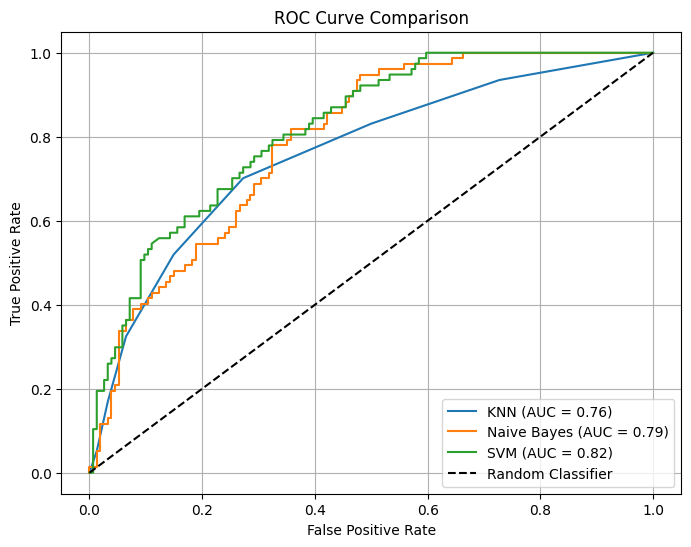

In [8]:
#model evaluation and plotting ROC curve

plt.figure(figsize=(8, 6))

#evaluating trained model
evaluate_model("KNN", Y_test, Y_pred_knn, knn.predict_proba(X_test)[:, 1])
evaluate_model("Naive Bayes", Y_test, Y_pred_nb, nb.predict_proba(X_test)[:, 1])
evaluate_model("SVM", Y_test, Y_pred_svm, svm_clf.predict_proba(X_test)[:, 1])

#plotting final baseline and display the chart
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc='lower right')
plt.grid()
plt.show()